# **Autoencoder-based Anomaly Detection Classifier**

This notebook implements an autoencoder-based classifier for anomaly detection. It demonstrates the process of loading data, preparing it for a deep learning model, defining an autoencoder architecture, training the autoencoder, and then building a classifier on top of the trained encoder. The notebook also explores different configurations for the classifier, including adding a learning rate scheduler and dropout for improved performance.

# **Loading the Dataset**

This section handles the initial loading of the dataset. The data is loaded from a `.npz` file, which typically contains NumPy arrays. The dataset is split into training, testing, and validation sets, and converted into PyTorch tensors suitable for model training. The `DEVICE` variable is also set to use a GPU if available, otherwise it defaults to CPU.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset

In [ ]:
project_data = np.load("/content/project_data.npz", allow_pickle=True)

X_train_np = project_data['X_train']
y_train_np = project_data['y_train']
X_test_np = project_data['X_test']
y_test_np = project_data['y_test']

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(DEVICE)

cuda


In [ ]:
class My_Dataset(Dataset):
  def __init__(self, X, y):
    self.X = torch.tensor(X, dtype=torch.float32).to(DEVICE)
    self.y = torch.tensor(y, dtype=torch.long).to(DEVICE)

  def __len__(self):
    return len(self.X)

  def __getitem__(self, idx):
    return self.X[idx], self.y[idx]

In [ ]:
train_dataset = My_Dataset(X_train_np, y_train_np)
test_dataset = My_Dataset(X_test_np, y_test_np)

This section defines and prepares the PyTorch `DataLoaders`. A custom `My_Dataset` class is created to encapsulate the input features (`X`) and target labels (`y`). The training dataset is further split into training and validation subsets. `DataLoaders` are then instantiated for training, validation, and testing, enabling efficient batch processing during model training.

# **DataLoaders**

In [ ]:
from torch.utils.data import DataLoader

validation = int(0.1* len(train_dataset))
train_dataset, validation_dataset = torch.utils.data.random_split(train_dataset, [len(train_dataset) - validation, validation])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
validation_loader = DataLoader(validation_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

In [ ]:
print(len(train_loader))
print(len(validation_loader))
print(len(test_loader))

1140
127
141


This section contains helper functions crucial for the autoencoder's training process. The `compute_loss_autoencoder` function calculates the Mean Squared Error (MSE) loss, which is typical for autoencoders, by comparing the model's output with its input. The `train_model_autoencoder` function orchestrates the training loop for the autoencoder, handling forward and backward passes, optimizer steps, and logging of loss values.

# **Helper Functions**

In [ ]:
def compute_loss_autoencoder(model, data_loader, device):

    total_loss = 0.0
    with torch.no_grad():
        for features, _ in data_loader:
            features = features.to(device)
            logits = model(features)
            loss = torch.nn.functional.mse_loss(logits, features)
            total_loss += loss.item()

    return total_loss / len(data_loader.dataset)


In [ ]:
import time
import torch

def train_model_autoencoder(model, num_epochs, train_loader,
                valid_loader, test_loader, optimizer,
                device, logging_interval=50,
                scheduler=None,
                scheduler_on='valid_acc'):

    start_time = time.time()
    minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []

    for epoch in range(num_epochs):
        # print("Length for epoch: ",epoch," = ",len(train_loader))
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):

            features = features.to(device)
            targets = targets.to(device)

            # ## FORWARD AND BACK PROP
            logits = model(features)

            loss = torch.nn.functional.mse_loss(logits, features)
            optimizer.zero_grad()

            loss.backward()

            # ## UPDATE MODEL PARAMETERS
            optimizer.step()

            # ## LOGGING
            minibatch_loss_list.append(loss.item())
            if not batch_idx % logging_interval:
                print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                      f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                      f'| Loss: {loss:.4f}')

        # model.eval()
        # with torch.no_grad():  # save memory during inference
        #     train_acc = compute_accuracy_autoencoder(model, train_loader, device=device)
        #     valid_acc = compute_accuracy_autoencoder(model, valid_loader, device=device)
        #     print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
        #           f'| Train: {train_acc :.2f}% '
        #           f'| Validation: {valid_acc :.2f}%')
        #     train_acc_list.append(train_acc)
        #     valid_acc_list.append(valid_acc)

        # elapsed = (time.time() - start_time)/60
        # print(f'Time elapsed: {elapsed:.2f} min')

        if scheduler is not None:

            if scheduler_on == 'valid_acc':
                scheduler.step(valid_acc_list[-1])
            elif scheduler_on == 'minibatch_loss':
                scheduler.step(minibatch_loss_list[-1])
            else:
                raise ValueError(f'Invalid `scheduler_on` choice.')


    elapsed = (time.time() - start_time)/60
    print(f'Total Training Time: {elapsed:.2f} min')

    # test_acc = compute_loss_autoencoder(model, test_loader, device=device)
    # print(f'Test accuracy {test_acc :.2f}%')

    return minibatch_loss_list, train_acc_list, valid_acc_list


The `plot_training_loss` function visualizes the minibatch loss over iterations and epochs, providing insight into the training progression. Although commented out, there are also placeholder functions for plotting accuracy, showing examples, and displaying a confusion matrix, which would be useful for a classification task built on top of the autoencoder.

In [ ]:
NUM_EPOCHS = 25

In [ ]:
# imports from installed libraries
import os
import matplotlib.pyplot as plt
import numpy as np
import torch


def plot_training_loss(minibatch_loss_list, num_epochs, iter_per_epoch,
                       results_dir=None, averaging_iterations=100):

    plt.figure()
    ax1 = plt.subplot(1, 1, 1)
    ax1.plot(range(len(minibatch_loss_list)),
             (minibatch_loss_list), label='Minibatch Loss')

    if len(minibatch_loss_list) > 1000:
        ax1.set_ylim([
            0, np.max(minibatch_loss_list[1000:])*1.5
            ])
    ax1.set_xlabel('Iterations')
    ax1.set_ylabel('Loss')

    ax1.plot(np.convolve(minibatch_loss_list,
                         np.ones(averaging_iterations,)/averaging_iterations,
                         mode='valid'),
             label='Running Average')
    ax1.legend()

    ###################
    # Set scond x-axis
    ax2 = ax1.twiny()
    newlabel = list(range(num_epochs+1))

    newpos = [e*iter_per_epoch for e in newlabel]

    ax2.set_xticks(newpos[::10])
    ax2.set_xticklabels(newlabel[::10])

    ax2.xaxis.set_ticks_position('bottom')
    ax2.xaxis.set_label_position('bottom')
    ax2.spines['bottom'].set_position(('outward', 45))
    ax2.set_xlabel('Epochs')
    ax2.set_xlim(ax1.get_xlim())
    ###################

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(results_dir, 'plot_training_loss.pdf')
        plt.savefig(image_path)


def plot_accuracy(train_acc_list, valid_acc_list, results_dir):

    num_epochs = len(train_acc_list)

    plt.plot(np.arange(1, num_epochs+1),
             train_acc_list, label='Training')
    plt.plot(np.arange(1, num_epochs+1),
             valid_acc_list, label='Validation')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()

    if results_dir is not None:
        image_path = os.path.join(
            results_dir, 'plot_acc_training_validation.pdf')
        plt.savefig(image_path)


def show_examples(model, data_loader, unnormalizer=None, class_dict=None):


    for batch_idx, (features, targets) in enumerate(data_loader):

        with torch.no_grad():
            features = features
            targets = targets
            logits = model(features)
            predictions = torch.argmax(logits, dim=1)
        break

    fig, axes = plt.subplots(nrows=3, ncols=5,
                             sharex=True, sharey=True)

    if unnormalizer is not None:
        for idx in range(features.shape[0]):
            features[idx] = unnormalizer(features[idx])
    nhwc_img = np.transpose(features, axes=(0, 2, 3, 1))

    if nhwc_img.shape[-1] == 1:
        nhw_img = np.squeeze(nhwc_img.numpy(), axis=3)

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhw_img[idx], cmap='binary')
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False

    else:

        for idx, ax in enumerate(axes.ravel()):
            ax.imshow(nhwc_img[idx])
            if class_dict is not None:
                ax.title.set_text(f'P: {class_dict[predictions[idx].item()]}'
                                  f'\nT: {class_dict[targets[idx].item()]}')
            else:
                ax.title.set_text(f'P: {predictions[idx]} | T: {targets[idx]}')
            ax.axison = False
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(conf_mat,
                          hide_spines=False,
                          hide_ticks=False,
                          figsize=None,
                          cmap=None,
                          colorbar=False,
                          show_absolute=True,
                          show_normed=False,
                          class_names=None):

    if not (show_absolute or show_normed):
        raise AssertionError('Both show_absolute and show_normed are False')
    if class_names is not None and len(class_names) != len(conf_mat):
        raise AssertionError('len(class_names) should be equal to number of'
                             'classes in the dataset')

    total_samples = conf_mat.sum(axis=1)[:, np.newaxis]
    normed_conf_mat = conf_mat.astype('float') / total_samples

    fig, ax = plt.subplots(figsize=figsize)
    ax.grid(False)
    if cmap is None:
        cmap = plt.cm.Blues

    if figsize is None:
        figsize = (len(conf_mat)*1.25, len(conf_mat)*1.25)

    if show_normed:
        matshow = ax.matshow(normed_conf_mat, cmap=cmap)
    else:
        matshow = ax.matshow(conf_mat, cmap=cmap)

    if colorbar:
        fig.colorbar(matshow)

    for i in range(conf_mat.shape[0]):
        for j in range(conf_mat.shape[1]):
            cell_text = ""
            if show_absolute:
                cell_text += format(conf_mat[i, j], 'd')
                if show_normed:
                    cell_text += "\n" + '('
                    cell_text += format(normed_conf_mat[i, j], '.2f') + ')'
            else:
                cell_text += format(normed_conf_mat[i, j], '.2f')
            ax.text(x=j,
                    y=i,
                    s=cell_text,
                    va='center',
                    ha='center',
                    color="white" if normed_conf_mat[i, j] > 0.5 else "black")

    if class_names is not None:
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names, rotation=90)
        plt.yticks(tick_marks, class_names)

    if hide_spines:
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False)
        ax.spines['left'].set_visible(False)
        ax.spines['bottom'].set_visible(False)
    ax.yaxis.set_ticks_position('left')
    ax.xaxis.set_ticks_position('bottom')
    if hide_ticks:
        ax.axes.get_yaxis().set_ticks([])
        ax.axes.get_xaxis().set_ticks([])

    plt.xlabel('predicted label')
    plt.ylabel('true label')
    return fig, ax

# **Autoencoder Model Definition**

Here, the `Autoencoder` model architecture is defined using PyTorch's `nn.Module`. It consists of an encoder and a decoder. The encoder maps the input data to a lower-dimensional latent space, and the decoder attempts to reconstruct the original input from this latent representation. This setup is fundamental for learning meaningful feature representations that can be used for tasks like anomaly detection.

In [ ]:
class Autoencoder(torch.nn.Module):
    def __init__(self):
        super(Autoencoder, self).__init__()

        #Encoder
        self.encoder = torch.nn.Sequential(
            torch.nn.Conv1d(in_channels=8, out_channels=16, kernel_size=3, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.Conv1d(16, 32, kernel_size=3, stride=2, padding=1),
            torch.nn.ReLU(),
            torch.nn.Flatten(),
            torch.nn.Linear(448, 10)
        )

        #Decoder
        self.decoder = torch.nn.Sequential(
            torch.nn.Linear(10, 32 * 14),
            torch.nn.Unflatten(1, (32, 14)),
            torch.nn.ConvTranspose1d(32, 16, kernel_size=3, stride=2, padding=1, output_padding=1),
            torch.nn.ReLU(),
            torch.nn.ConvTranspose1d(16, 8, kernel_size=3, stride=2, padding=1, output_padding=0),
        )

    def encode(self, x):
        x = x.permute(0, 2, 1) #[32,8,5]
        latent = self.encoder(x)  #[32,10]
        return latent

    def decode(self, latent):
        x = self.decoder(latent)  #[32,8,55]
        x = x.permute(0, 2, 1)  #[32,55,8]
        return x

    def forward(self, x):
        latent = self.encode(x)
        return self.decode(latent)


In [ ]:
autoencoder = Autoencoder()

autoencoder.to(DEVICE)

optimizer = torch.optim.Adam(autoencoder.parameters(), lr=0.0001)

This code initializes an instance of the `Autoencoder` model, moves it to the appropriate `DEVICE` (GPU or CPU), and sets up the Adam optimizer with a learning rate of `0.0001`. It then calls the `train_model_autoencoder` function to train the autoencoder for a specified number of epochs (`NUM_EPOCHS`). The output shows the loss decreasing over epochs, indicating that the autoencoder is learning to reconstruct the input data.

In [ ]:
minibatch_loss_list, train_acc_list, valid_acc_list = train_model_autoencoder(
    model = autoencoder,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = validation_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)


Epoch: 001/025 | Batch 0000/1140 | Loss: 12372270.0000
Epoch: 001/025 | Batch 0050/1140 | Loss: 11159862.0000
Epoch: 001/025 | Batch 0100/1140 | Loss: 9896538.0000
Epoch: 001/025 | Batch 0150/1140 | Loss: 8042719.0000
Epoch: 001/025 | Batch 0200/1140 | Loss: 5958352.0000
Epoch: 001/025 | Batch 0250/1140 | Loss: 5028253.0000
Epoch: 001/025 | Batch 0300/1140 | Loss: 4164013.0000
Epoch: 001/025 | Batch 0350/1140 | Loss: 3926003.0000
Epoch: 001/025 | Batch 0400/1140 | Loss: 3661846.0000
Epoch: 001/025 | Batch 0450/1140 | Loss: 3249564.0000
Epoch: 001/025 | Batch 0500/1140 | Loss: 2790950.5000
Epoch: 001/025 | Batch 0550/1140 | Loss: 2804248.7500
Epoch: 001/025 | Batch 0600/1140 | Loss: 2555322.0000
Epoch: 001/025 | Batch 0650/1140 | Loss: 2561325.5000
Epoch: 001/025 | Batch 0700/1140 | Loss: 2213615.7500
Epoch: 001/025 | Batch 0750/1140 | Loss: 2251958.0000
Epoch: 001/025 | Batch 0800/1140 | Loss: 2068287.8750
Epoch: 001/025 | Batch 0850/1140 | Loss: 2319057.7500
Epoch: 001/025 | Batch 090

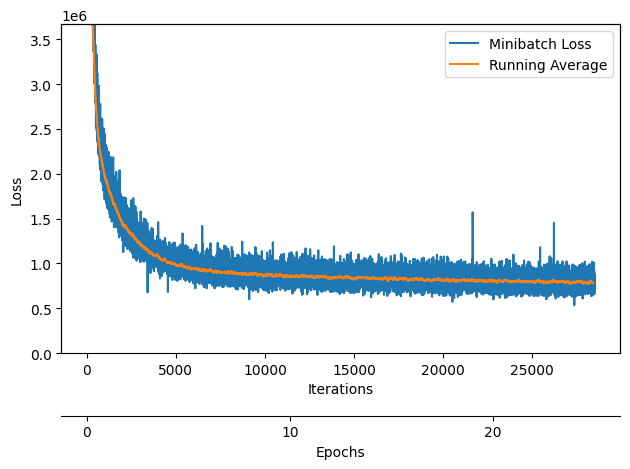

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

# plot_accuracy(train_acc_list=train_acc_list,
#               valid_acc_list=valid_acc_list,
#               results_dir=None)
# plt.show()

# **Helper Functions - Classifier**

This section provides helper functions specifically designed for the classification task. These include `set_all_seeds` and `set_deterministic` for reproducibility, `compute_accuracy` to evaluate the classifier's performance, and `compute_confusion_matrix` to analyze the types of errors made by the classifier. The `train_model_classifier` function is an adapted version of the training loop for classification, using `cross_entropy` loss and logging training and validation accuracies.

In [ ]:
# imports from installed libraries
import os
import numpy as np
import random
import torch
from distutils.version import LooseVersion as Version
from itertools import product


def set_all_seeds(seed):
    os.environ["PL_GLOBAL_SEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def set_deterministic():
    if torch.cuda.is_available():
        torch.backends.cudnn.benchmark = False
        torch.backends.cudnn.deterministic = True

    if torch.__version__ <= Version("1.7"):
        torch.set_deterministic(True)
    else:
        torch.use_deterministic_algorithms(True)


def compute_accuracy(model, data_loader, device):

    with torch.no_grad():

        correct_pred, num_examples = 0, 0

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets.float().to(device)

            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)

            num_examples += targets.size(0)
            correct_pred += (predicted_labels == targets).sum()
    return correct_pred.float()/num_examples * 100


def compute_confusion_matrix(model, data_loader, device):

    all_targets, all_predictions = [], []
    with torch.no_grad():

        for i, (features, targets) in enumerate(data_loader):

            features = features.to(device)
            targets = targets
            logits = model(features)
            _, predicted_labels = torch.max(logits, 1)
            all_targets.extend(targets.to('cpu'))
            all_predictions.extend(predicted_labels.to('cpu'))

    all_predictions = all_predictions
    all_predictions = np.array(all_predictions)
    all_targets = np.array(all_targets)

    class_labels = np.unique(np.concatenate((all_targets, all_predictions)))
    if class_labels.shape[0] == 1:
        if class_labels[0] != 0:
            class_labels = np.array([0, class_labels[0]])
        else:
            class_labels = np.array([class_labels[0], 1])
    n_labels = class_labels.shape[0]
    lst = []
    z = list(zip(all_targets, all_predictions))
    for combi in product(class_labels, repeat=2):
        lst.append(z.count(combi))
    mat = np.asarray(lst)[:, None].reshape(n_labels, n_labels)
    return mat

In [ ]:
import time
import torch

def train_model_classifier(model, num_epochs, train_loader,
                valid_loader, test_loader, optimizer,
                device, logging_interval=50,
                scheduler=None,
                scheduler_on='valid_acc'):

    start_time = time.time()
    minibatch_loss_list, train_acc_list, valid_acc_list = [], [], []

    for epoch in range(num_epochs):
        # print("Length for epoch: ",epoch," = ",len(train_loader))
        model.train()
        for batch_idx, (features, targets) in enumerate(train_loader):

            features = features.to(device)
            targets = targets.to(device)

            # ## FORWARD AND BACK PROP
            logits = model(features)
            loss = torch.nn.functional.cross_entropy(logits, targets)
            optimizer.zero_grad()

            loss.backward()

            # ## UPDATE MODEL PARAMETERS
            optimizer.step()

            # ## LOGGING
            minibatch_loss_list.append(loss.item())
            if not batch_idx % logging_interval:
                print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                      f'| Batch {batch_idx:04d}/{len(train_loader):04d} '
                      f'| Loss: {loss:.4f}')

        model.eval()
        with torch.no_grad():  # save memory during inference
            train_acc = compute_accuracy(model, train_loader, device=device)
            valid_acc = compute_accuracy(model, valid_loader, device=device)
            print(f'Epoch: {epoch+1:03d}/{num_epochs:03d} '
                  f'| Train: {train_acc :.2f}% '
                  f'| Validation: {valid_acc :.2f}%')
            train_acc_list.append(train_acc.item())
            valid_acc_list.append(valid_acc.item())

        elapsed = (time.time() - start_time)/60
        print(f'Time elapsed: {elapsed:.2f} min')

        if scheduler is not None:

            if scheduler_on == 'valid_acc':
                scheduler.step(valid_acc_list[-1])
            elif scheduler_on == 'minibatch_loss':
                scheduler.step(minibatch_loss_list[-1])
            else:
                raise ValueError(f'Invalid `scheduler_on` choice.')


    elapsed = (time.time() - start_time)/60
    print(f'Total Training Time: {elapsed:.2f} min')

    test_acc = compute_accuracy(model, test_loader, device=device)
    print(f'Test accuracy {test_acc :.2f}%')

    return minibatch_loss_list, train_acc_list, valid_acc_list


The `plot_training_loss` and `plot_accuracy` functions from the previous helper section are reiterated here for clarity, specifically for visualizing the training process of the classifier models.

# **Classifier Definition**

The `AutoencoderClassifier` class defines the classification model. It reuses the pre-trained encoder from the `Autoencoder` model and appends a classification head (a series of linear layers and a ReLU activation) to the latent representation. This approach leverages the feature extraction capabilities of the autoencoder for the downstream classification task.

In [ ]:
class AutoencoderClassifier(torch.nn.Module):
    def __init__(self, autoencoder, num_classes=10):
        super(AutoencoderClassifier, self).__init__()
        self.encoder = autoencoder.encoder
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(10, 32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        latent = self.encoder(x)
        out = self.classifier(latent)
        return out


# **Step 1**

This block initializes and trains the `AutoencoderClassifier` without any additional regularization techniques beyond the basic setup. It demonstrates the initial performance of the classifier built on the autoencoder's latent space. The output shows the training progression and the final test accuracy.

In [ ]:
classifier = AutoencoderClassifier(autoencoder, 11)

classifier.to(DEVICE)

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model_classifier(
    model = classifier,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = validation_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = None,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/1140 | Loss: 4938.7559
Epoch: 001/025 | Batch 0050/1140 | Loss: 359.8628
Epoch: 001/025 | Batch 0100/1140 | Loss: 233.3139
Epoch: 001/025 | Batch 0150/1140 | Loss: 42.6839
Epoch: 001/025 | Batch 0200/1140 | Loss: 69.5442
Epoch: 001/025 | Batch 0250/1140 | Loss: 41.0661
Epoch: 001/025 | Batch 0300/1140 | Loss: 52.8372
Epoch: 001/025 | Batch 0350/1140 | Loss: 38.2669
Epoch: 001/025 | Batch 0400/1140 | Loss: 36.0846
Epoch: 001/025 | Batch 0450/1140 | Loss: 20.4948
Epoch: 001/025 | Batch 0500/1140 | Loss: 12.7148
Epoch: 001/025 | Batch 0550/1140 | Loss: 13.9904
Epoch: 001/025 | Batch 0600/1140 | Loss: 21.5470
Epoch: 001/025 | Batch 0650/1140 | Loss: 10.8513
Epoch: 001/025 | Batch 0700/1140 | Loss: 12.6563
Epoch: 001/025 | Batch 0750/1140 | Loss: 11.2659
Epoch: 001/025 | Batch 0800/1140 | Loss: 4.2872
Epoch: 001/025 | Batch 0850/1140 | Loss: 8.6565
Epoch: 001/025 | Batch 0900/1140 | Loss: 7.3450
Epoch: 001/025 | Batch 0950/1140 | Loss: 4.8484
Epoch: 001/025 | Bat

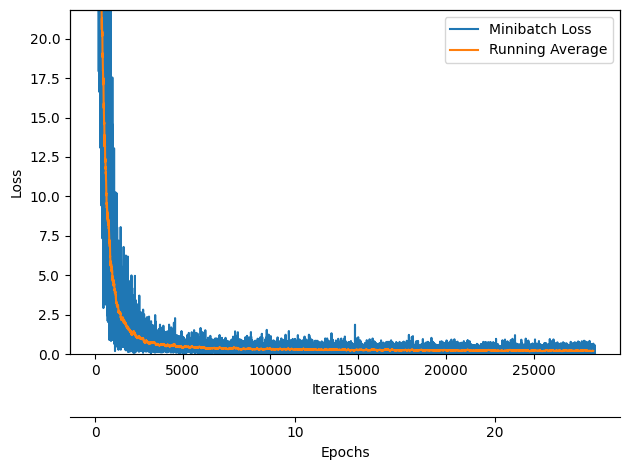

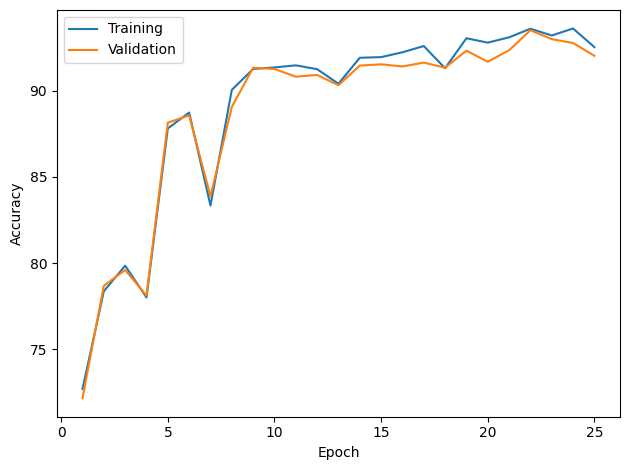

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Step 2**

In this step, a `ReduceLROnPlateau` scheduler is introduced to dynamically adjust the learning rate during training. This scheduler reduces the learning rate when the validation accuracy stops improving, which can help the model converge more effectively and avoid overfitting. The updated training logs reflect the impact of the scheduler on learning.

In [ ]:
classifier = AutoencoderClassifier(autoencoder, 11)

classifier.to(DEVICE)

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode='max',
                                                       factor=0.5)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model_classifier(
    model = classifier,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = validation_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = scheduler,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/1140 | Loss: 84.3449
Epoch: 001/025 | Batch 0050/1140 | Loss: 1.6674
Epoch: 001/025 | Batch 0100/1140 | Loss: 1.2243
Epoch: 001/025 | Batch 0150/1140 | Loss: 0.8806
Epoch: 001/025 | Batch 0200/1140 | Loss: 1.0609
Epoch: 001/025 | Batch 0250/1140 | Loss: 0.8122
Epoch: 001/025 | Batch 0300/1140 | Loss: 0.7642
Epoch: 001/025 | Batch 0350/1140 | Loss: 0.7453
Epoch: 001/025 | Batch 0400/1140 | Loss: 0.6887
Epoch: 001/025 | Batch 0450/1140 | Loss: 0.3868
Epoch: 001/025 | Batch 0500/1140 | Loss: 0.8477
Epoch: 001/025 | Batch 0550/1140 | Loss: 0.4208
Epoch: 001/025 | Batch 0600/1140 | Loss: 0.5541
Epoch: 001/025 | Batch 0650/1140 | Loss: 0.2274
Epoch: 001/025 | Batch 0700/1140 | Loss: 0.6980
Epoch: 001/025 | Batch 0750/1140 | Loss: 0.7612
Epoch: 001/025 | Batch 0800/1140 | Loss: 0.5985
Epoch: 001/025 | Batch 0850/1140 | Loss: 0.3099
Epoch: 001/025 | Batch 0900/1140 | Loss: 0.3449
Epoch: 001/025 | Batch 0950/1140 | Loss: 0.5915
Epoch: 001/025 | Batch 1000/1140 | Loss

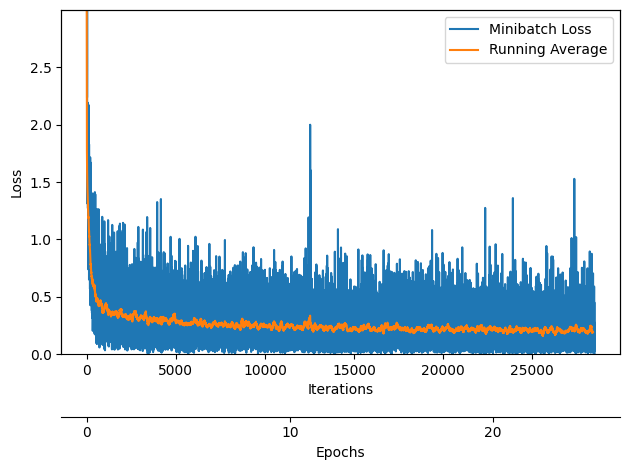

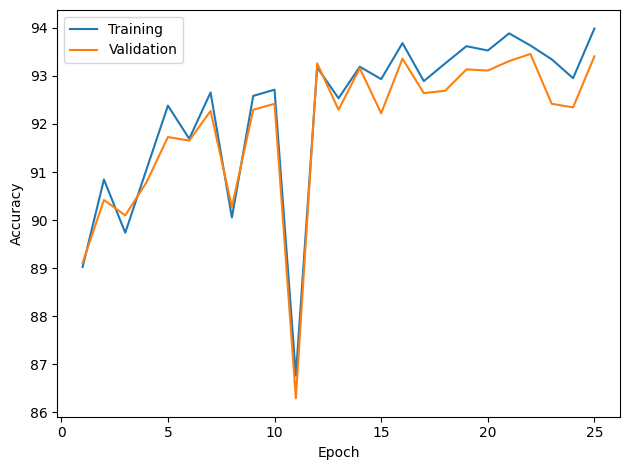

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Step 3**

In [ ]:
class AutoencoderClassifier(torch.nn.Module):
    def __init__(self, autoencoder, num_classes=10):
        super(AutoencoderClassifier, self).__init__()
        self.encoder = autoencoder.encoder
        self.classifier = torch.nn.Sequential(
            torch.nn.Linear(10, 32),
            torch.nn.BatchNorm1d(32),
            torch.nn.ReLU(),
            torch.nn.Linear(32, num_classes)
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        latent = self.encoder(x)
        out = self.classifier(latent)
        return out


This step enhances the `AutoencoderClassifier` by adding a `BatchNorm1d` layer to the classifier head. Batch Normalization helps to stabilize and accelerate the training of deep neural networks by normalizing the inputs to each layer. It can lead to faster convergence and improved performance. Note that the number of epochs is `NUM_EPOCHS-1` here, potentially to compare with earlier steps or for a specific experimental design.

In [ ]:
classifier = AutoencoderClassifier(autoencoder, 11)

classifier.to(DEVICE)

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode='max',
                                                       factor=0.5)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model_classifier(
    model = classifier,
    num_epochs = NUM_EPOCHS-1,
    train_loader = train_loader,
    valid_loader = validation_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = scheduler,
    scheduler_on = 'valid_acc'
)

Epoch: 001/024 | Batch 0000/1140 | Loss: 2.4705
Epoch: 001/024 | Batch 0050/1140 | Loss: 1.2408
Epoch: 001/024 | Batch 0100/1140 | Loss: 0.9040
Epoch: 001/024 | Batch 0150/1140 | Loss: 0.5865
Epoch: 001/024 | Batch 0200/1140 | Loss: 0.3779
Epoch: 001/024 | Batch 0250/1140 | Loss: 0.6464
Epoch: 001/024 | Batch 0300/1140 | Loss: 0.2190
Epoch: 001/024 | Batch 0350/1140 | Loss: 0.6471
Epoch: 001/024 | Batch 0400/1140 | Loss: 0.1855
Epoch: 001/024 | Batch 0450/1140 | Loss: 0.3864
Epoch: 001/024 | Batch 0500/1140 | Loss: 0.3083
Epoch: 001/024 | Batch 0550/1140 | Loss: 0.1615
Epoch: 001/024 | Batch 0600/1140 | Loss: 0.3426
Epoch: 001/024 | Batch 0650/1140 | Loss: 0.1444
Epoch: 001/024 | Batch 0700/1140 | Loss: 0.1169
Epoch: 001/024 | Batch 0750/1140 | Loss: 0.1969
Epoch: 001/024 | Batch 0800/1140 | Loss: 0.1408
Epoch: 001/024 | Batch 0850/1140 | Loss: 0.1570
Epoch: 001/024 | Batch 0900/1140 | Loss: 0.0793
Epoch: 001/024 | Batch 0950/1140 | Loss: 0.0608
Epoch: 001/024 | Batch 1000/1140 | Loss:

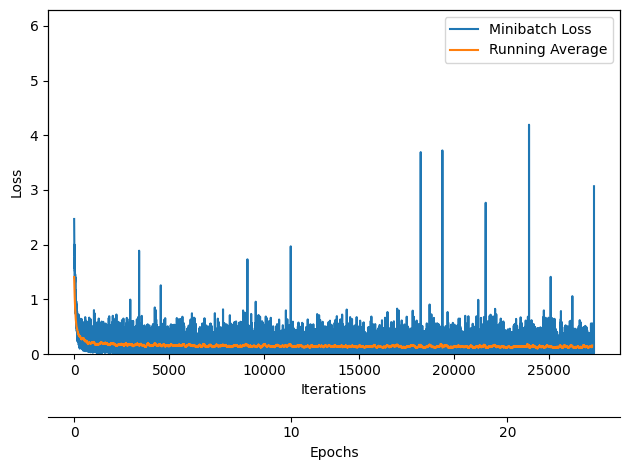

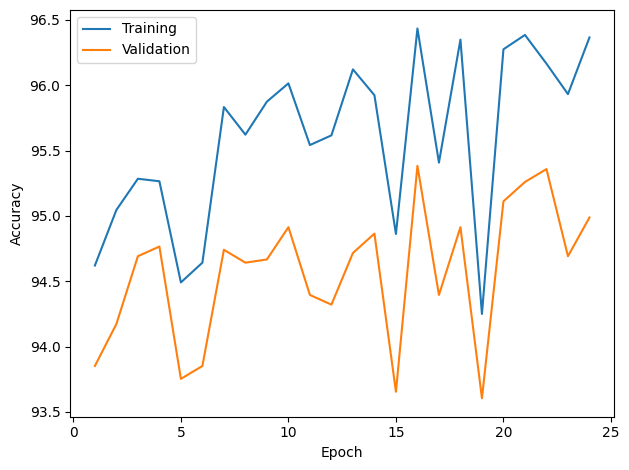

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS-1,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Step 4**

Building on previous improvements, this step introduces a `Dropout` layer into the `AutoencoderClassifier`'s classification head. Dropout is a regularization technique that randomly sets a fraction of input units to zero at each update during training, which helps prevent overfitting by forcing the network to learn more robust features. The `dropout_prob` parameter controls the dropout rate.

In [ ]:
class AutoencoderClassifier(torch.nn.Module):
  def __init__(self, autoencoder, num_classes, dropout_prob):
    super(AutoencoderClassifier, self).__init__()
    self.encoder = autoencoder.encoder
    self.classifier = torch.nn.Sequential(
        torch.nn.Linear(10, 32),
        torch.nn.BatchNorm1d(32),
        torch.nn.ReLU(),
        torch.nn.Dropout(p=dropout_prob),
        torch.nn.Linear(32, num_classes)
    )

  def forward(self, x):
    x = x.permute(0, 2, 1)
    latent = self.encoder(x)
    out = self.classifier(latent)
    return out


In [ ]:
classifier = AutoencoderClassifier(autoencoder, 11, 0.3)

classifier.to(DEVICE)

optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer,
                                                       mode='max',
                                                       factor=0.5)

minibatch_loss_list, train_acc_list, valid_acc_list = train_model_classifier(
    model = classifier,
    num_epochs = NUM_EPOCHS,
    train_loader = train_loader,
    valid_loader = validation_loader,
    test_loader = test_loader,
    optimizer = optimizer,
    device = DEVICE,
    logging_interval = 50,
    scheduler = scheduler,
    scheduler_on = 'valid_acc'
)

Epoch: 001/025 | Batch 0000/1140 | Loss: 2.7105
Epoch: 001/025 | Batch 0050/1140 | Loss: 1.3508
Epoch: 001/025 | Batch 0100/1140 | Loss: 0.8070
Epoch: 001/025 | Batch 0150/1140 | Loss: 0.6588
Epoch: 001/025 | Batch 0200/1140 | Loss: 0.4850
Epoch: 001/025 | Batch 0250/1140 | Loss: 0.4863
Epoch: 001/025 | Batch 0300/1140 | Loss: 0.4702
Epoch: 001/025 | Batch 0350/1140 | Loss: 0.3701
Epoch: 001/025 | Batch 0400/1140 | Loss: 0.2478
Epoch: 001/025 | Batch 0450/1140 | Loss: 0.4815
Epoch: 001/025 | Batch 0500/1140 | Loss: 0.1852
Epoch: 001/025 | Batch 0550/1140 | Loss: 0.1977
Epoch: 001/025 | Batch 0600/1140 | Loss: 0.1637
Epoch: 001/025 | Batch 0650/1140 | Loss: 0.3270
Epoch: 001/025 | Batch 0700/1140 | Loss: 0.3477
Epoch: 001/025 | Batch 0750/1140 | Loss: 0.1460
Epoch: 001/025 | Batch 0800/1140 | Loss: 0.2361
Epoch: 001/025 | Batch 0850/1140 | Loss: 0.3762
Epoch: 001/025 | Batch 0900/1140 | Loss: 0.2873
Epoch: 001/025 | Batch 0950/1140 | Loss: 0.5630
Epoch: 001/025 | Batch 1000/1140 | Loss:

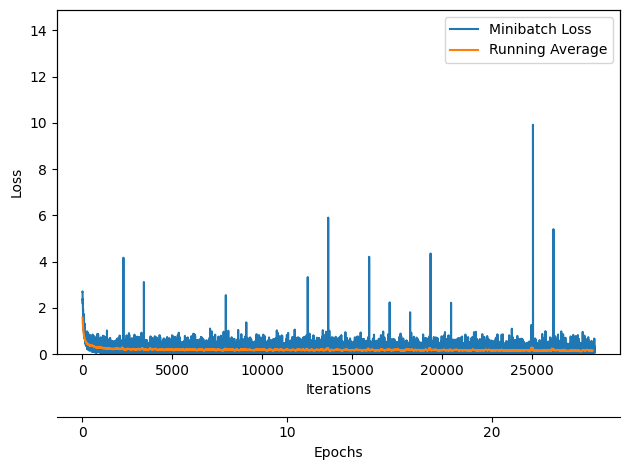

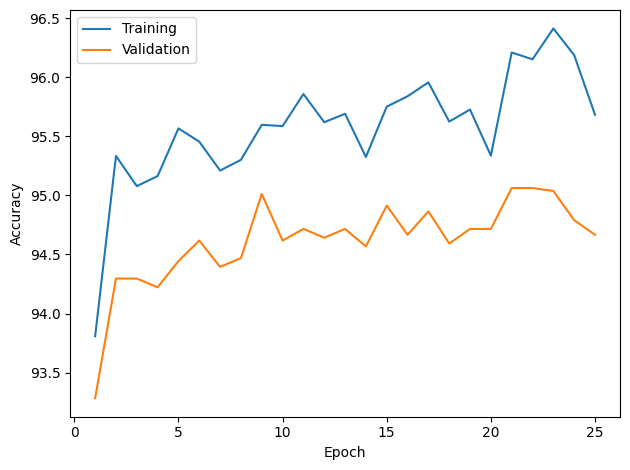

In [ ]:
plot_training_loss(minibatch_loss_list=minibatch_loss_list,
                   num_epochs=NUM_EPOCHS,
                   iter_per_epoch=len(train_loader),
                   results_dir=None,
                   averaging_iterations=100)
plt.show()

plot_accuracy(train_acc_list=train_acc_list,
              valid_acc_list=valid_acc_list,
              results_dir=None)
plt.show()

# **Saving the best model**

This final section is dedicated to saving the trained classifier model. The `torch.save` function is used to serialize the model's state dictionary to a file named `autoencoder_best_model.pt`. This allows the trained model to be loaded and reused later without needing to retrain it. The `files.download` command is included to facilitate downloading the saved model from the Colab environment.

In [ ]:
torch.save(classifier, 'autoencoder_best_model.pt')

from google.colab import files
files.download('autoencoder_best_model.pt')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>